## 1 Overview

### 1.1 Problem Statement

### 1.2 About Dataset

1. `Request id`: Trip request id.
2. `Pickup point`: Pickup point of trip.
   - `Airport`: Trip picked up from Airport to City.
   - `City`: Trip picked up from City to Airport.
3. `Driver id`: Driver's id number.
4. `Status`: Three types of trip status.
   - `Trip Completed`
   - `Cancelled`
   - `No Cars Available`
5. `Request timestamp`: Date and time when trip request was raised.
6. `Drop timestamp`: Date and time when customer was dropped at location.

### 1.3 Objective

Perform Root Cause Analysis (RCA) to identify the root cause of trip cancellation.

To achieve this objective perform:

1. Exploratory data analysis on dataset.
2. Perform Feature Engineering.
3. Define and analyze Metrics.

## 2 Setup

### 2.1 Libraries

#### Import Libraries

In [1]:
import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt
import seaborn as sns

#### Configure Libraries

In [2]:
# Configure NumPy.
np.random.seed(42)

# Configure Seaborn.
sns.set_style("whitegrid")
sns.set_palette("deep")

#### Constants and Helper Functions

In [3]:
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

In [4]:
def caculate_metrics(df: pd.DataFrame, for_col: str):
    """
    Function to compute metrics:
        1. Demand Supply Gap.
        2. Availability rate.
        3. Cancellation rate.
    """
    return (
        df.groupby(by=for_col)
        .agg(
            demand=("req_id", "count"),
            supply=("status", lambda x: (x == "Completed").sum()),
            avblty_count=("status", lambda x: (x != "Unavailable").sum()),
            cancel_count=("status", lambda x: (x == "Canceled").sum()),
        )
        .assign(
            ds_gap=lambda df: ((df["demand"] - df["supply"]) / df["demand"]).round(4),
            avblty_rate=lambda df: (df["avblty_count"] / df["demand"]).round(4),
            cancel_rate=lambda df: (df["cancel_count"] / df["demand"]).round(4),
        )
        .reset_index()
    )

### 2.2 Dataset

#### Import dataset

In [5]:
ub_df = pd.read_csv("data/uber-data.csv")

row_count, col_count = ub_df.shape
display(ub_df.sample(5, random_state=16))
print(f"Dataset has {row_count} rows and {col_count} columns.")

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
2898,5208,Airport,20.0,Cancelled,14-07-2016 20:55:57,NaN
326,1478,City,33.0,Trip Completed,12/7/2016 5:16,12/7/2016 6:13
6649,6552,Airport,NaN,No Cars Available,15-07-2016 21:08:54,NaN
1902,6007,City,199.0,Trip Completed,15-07-2016 12:15:42,15-07-2016 13:03:40
4557,1257,Airport,NaN,No Cars Available,11/7/2016 21:55,NaN


Dataset has 6745 rows and 6 columns.


### 2.3 Data Profiling

In [6]:
ub_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   str    
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   str    
 4   Request timestamp  6745 non-null   str    
 5   Drop timestamp     2831 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 316.3 KB


#### 1 Feature types

##### Categorical Features

1. Pickup point
2. Status

##### Numerical Features

1. Request id
2. Driver id

##### Temporal Features

1. Request timestamp
2. Drop timestamp

#### 2 Cardinality

In [7]:
ub_df.nunique()

Request id           6745
Pickup point            2
Driver id             300
Status                  3
Request timestamp    5618
Drop timestamp       2598
dtype: int64

In [8]:
ub_df["Pickup point"].value_counts()

Pickup point
City       3507
Airport    3238
Name: count, dtype: int64

In [9]:
ub_df["Status"].value_counts()

Status
Trip Completed       2831
No Cars Available    2650
Cancelled            1264
Name: count, dtype: int64

#### 3 Rename Columns

In [10]:
col_name_mapping = {
    "Request id": "req_id",
    "Pickup point": "pickup",
    "Driver id": "dvr_id",
    "Status": "status",
    "Request timestamp": "req_dt",
    "Drop timestamp": "drp_dt",
}
ub_df.rename(columns=col_name_mapping, inplace=True)

## 3 Data Wrangling

### 3.1 Duplicates check

In [11]:
dup_count = ub_df.duplicated().sum()
print(f"Dataset has {dup_count} duplicate rows.")

Dataset has 0 duplicate rows.


### 3.2 Handling Null values

In [12]:
ub_df.isna().sum()

req_id       0
pickup       0
dvr_id    2650
status       0
req_dt       0
drp_dt    3914
dtype: int64

In [13]:
mask = ub_df["dvr_id"].isna()
ub_df[mask]["status"].value_counts()

status
No Cars Available    2650
Name: count, dtype: int64

In [14]:
mask = ub_df["drp_dt"].isna()
ub_df[mask]["status"].value_counts()

status
No Cars Available    2650
Cancelled            1264
Name: count, dtype: int64

### 3.3 Type Casting

#### request/drop timestamps to date-time object

In [15]:
ub_df.loc[[326, 1902, 4557], ["req_dt", "drp_dt"]]

,req_dt,drp_dt
326,12/7/2016 5:16,12/7/2016 6:13
1902,15-07-2016 12:15:42,15-07-2016 13:03:40
4557,11/7/2016 21:55,NaN


In [16]:
ub_df["req_dt"] = pd.to_datetime(ub_df["req_dt"], format="mixed", dayfirst=True)
ub_df["drp_dt"] = pd.to_datetime(ub_df["drp_dt"], format="mixed", dayfirst=True)

In [17]:
ub_df.loc[[326, 1902, 4557], ["req_dt", "drp_dt"]]

,req_dt,drp_dt
326,2016-07-12 05:16:00,2016-07-12 06:13:00
1902,2016-07-15 12:15:42,2016-07-15 13:03:40
4557,2016-07-11 21:55:00,NaT


#### Status to category

In [18]:
status_map = {
    "Cancelled": "Canceled",
    "No Cars Available": "Unavailable",
    "Trip Completed": "Completed",
}
status_order = list(status_map.values())

# Convert 'status' column to a categorical type in the specified order.
ub_df["status"] = pd.Categorical(
    ub_df["status"].map(status_map),
    categories=status_order,
    ordered=True,
)

ub_df["status"].value_counts()

status
Completed      2831
Unavailable    2650
Canceled       1264
Name: count, dtype: int64

> **Note**:
>
> The spelling mistake in trip status "Cancelled" was also corrected to "Canceled" while mapping.

#### Pickup type to category

In [19]:
pickup_map = {
    "Airport": "Airport to City",
    "City": "City to Airport",
}

# Convert 'pickup' column to a categorical type.
ub_df["pickup"] = ub_df["pickup"].map(pickup_map).astype("category")
ub_df["pickup"].value_counts()

pickup
City to Airport    3507
Airport to City    3238
Name: count, dtype: int64

### 3.4 Data Validation

In [20]:
mask = ub_df["drp_dt"] < ub_df["req_dt"]
ub_df[mask]

,req_id,pickup,dvr_id,status,req_dt,drp_dt


In [21]:
mask = ub_df["drp_dt"].isna()
ub_df[mask]["status"].value_counts()

status
Unavailable    2650
Canceled       1264
Completed         0
Name: count, dtype: int64

In [22]:
mask = ub_df["dvr_id"].isna()
ub_df[mask]["status"].value_counts()

status
Unavailable    2650
Canceled          0
Completed         0
Name: count, dtype: int64

## 4 Feature Engineering

### 4.1 Create New Features

#### Extract features from request date-time

In [23]:
ub_df["req_year"] = ub_df["req_dt"].dt.year.astype("Int32")
ub_df["req_month"] = ub_df["req_dt"].dt.month.astype("Int32")
ub_df["req_date"] = ub_df["req_dt"].dt.day.astype("Int32")
ub_df["req_wday"] = ub_df["req_dt"].dt.day_name().astype("category")
ub_df["req_hour"] = ub_df["req_dt"].dt.hour.astype("Int32")
ub_df["req_min"] = ub_df["req_dt"].dt.minute.astype("Int32")

ub_df[["req_dt", "req_year", "req_month", "req_date", "req_wday", "req_hour", "req_min"]].sample(3)

,req_dt,req_year,req_month,req_date,req_wday,req_hour,req_min
2531,2016-07-13 03:55:10,2016,7,13,Wednesday,3,55
4591,2016-07-11 23:30:00,2016,7,11,Monday,23,30
4127,2016-07-11 03:07:00,2016,7,11,Monday,3,7


#### Extract features from drop date-time

In [24]:
ub_df["drp_year"] = ub_df["drp_dt"].dt.year.astype("Int32")
ub_df["drp_month"] = ub_df["drp_dt"].dt.month.astype("Int32")
ub_df["drp_date"] = ub_df["drp_dt"].dt.day.astype("Int32")
ub_df["drp_wday"] = ub_df["drp_dt"].dt.day_name()
ub_df["drp_hour"] = ub_df["drp_dt"].dt.hour.astype("Int32")
ub_df["drp_min"] = ub_df["drp_dt"].dt.minute.astype("Int32")

ub_df[["drp_dt", "drp_year", "drp_month", "drp_date", "drp_wday", "drp_hour", "drp_min"]].sample(3)

,drp_dt,drp_year,drp_month,drp_date,drp_wday,drp_hour,drp_min
3858,NaT,<NA>,<NA>,<NA>,NaN,<NA>,<NA>
833,2016-07-13 21:43:20,2016,7,13,Wednesday,21,43
3288,NaT,<NA>,<NA>,<NA>,NaN,<NA>,<NA>


In [25]:
ub_df["req_year"].value_counts(), ub_df["drp_year"].value_counts()

(req_year
 2016    6745
 Name: count, dtype: Int64,
 drp_year
 2016    2831
 Name: count, dtype: Int64)

In [26]:
ub_df["req_month"].value_counts(), ub_df["drp_month"].value_counts()

(req_month
 7    6745
 Name: count, dtype: Int64,
 drp_month
 7    2831
 Name: count, dtype: Int64)

In [27]:
ub_df["req_date"].value_counts().sort_index()

req_date
11    1367
12    1307
13    1337
14    1353
15    1381
Name: count, dtype: Int64

##### Observations

1. Entire dataset is only of five days from 11-July-2016 to 15-July-2016.
2. Data of five days is insufficient to perform any yearly, monthly or daily analysis.
3. We will mostly focus on hourly analysis of data.

#### New Feature 'Time Difference'

In [28]:
ub_df["time_diff"] = ub_df["drp_dt"] - ub_df["req_dt"]
ub_df[["req_dt", "drp_dt", "time_diff"]].sample(3)

,req_dt,drp_dt,time_diff
5139,2016-07-13 02:37:05,NaT,NaT
6165,2016-07-15 00:09:09,NaT,NaT
4852,2016-07-12 18:20:00,NaT,NaT


#### New Feature Working Hours

In [29]:
hour_bins = [-1, 4, 8, 18, 23]
day_type = [
    "Mid Night",  # [12 AM, 4 AM]
    "Early Morning",  # [5 AM, 8 AM]
    "Working Hours",  # [9 AM, 6 PM]
    "Night",  # [7 PM , 11 PM]
]

ub_df["day_type"] = pd.cut(ub_df["req_hour"], bins=hour_bins, labels=day_type)

ub_df[["req_hour", "day_type"]].sample(3)

,req_hour,day_type
4389,18,Working Hours
3911,9,Working Hours
2476,6,Early Morning


### 4.2 Define New Metrics

1. Demand-Supply-Gap
2. Availability rate
3. Cancellation rate

#### 1 Demand-Supply-Gap

$$
\begin{aligned}
\text{Demand-Supply-Gap} = \frac{\text{Demand} - \text{Supply}}{\text{Demand}}
\end{aligned}
$$

##### Case #1

In [30]:
d = 100
s = 10
(d - s) / d

0.9

##### Case #2

In [31]:
d = 100
s = 100
(d - s) / d

0.0

##### Case #3

In [32]:
d = 10
s = 100
(d - s) / d

-9.0

#### 2 Availability rate

$$
\begin{aligned}
\text{Availability rate} = \frac{\text{Total number of processed requests}}{\text{Total number of requests}}
\end{aligned}
$$

A request is considered as:

1. **processed** if a driver was assigned (but the trip can be completed/canceled).
2. **unprocessed** if a driver was not assigned (trip status "No Cars Available").

#### 3 Cancellation rate

$$
\begin{aligned}
\text{Cancellation rate} = \frac{\text{Total number of canceled requests}}{\text{Total number of requests}}
\end{aligned}
$$

### 4.3 Crate Features for Metrics

#### 1 Daily Metrics

In [33]:
dlm_df = caculate_metrics(ub_df, "req_date")
dlm_df

,req_date,demand,supply,avblty_count,cancel_count,ds_gap,avblty_rate,cancel_rate
0,11,1367,601,863,262,0.5604,0.6313,0.1917
1,12,1307,562,802,240,0.5700,0.6136,0.1836
2,13,1337,577,847,270,0.5684,0.6335,0.2019
3,14,1353,530,782,252,0.6083,0.5780,0.1863
4,15,1381,561,801,240,0.5938,0.5800,0.1738


#### 2 Weekly Metrics

In [34]:
wkm_df = caculate_metrics(ub_df, "req_wday")

wd_cat_type = CategoricalDtype(categories=weekdays, ordered=True)
wkm_df["req_wday"] = wkm_df["req_wday"].astype(wd_cat_type)
wkm_df = wkm_df.sort_values(by="req_wday")

wkm_df

,req_wday,demand,supply,avblty_count,cancel_count,ds_gap,avblty_rate,cancel_rate
1,Monday,1367,601,863,262,0.5604,0.6313,0.1917
3,Tuesday,1307,562,802,240,0.5700,0.6136,0.1836
4,Wednesday,1337,577,847,270,0.5684,0.6335,0.2019
2,Thursday,1353,530,782,252,0.6083,0.5780,0.1863
0,Friday,1381,561,801,240,0.5938,0.5800,0.1738


#### 3 Hourly Metrics

In [35]:
hrm_df = caculate_metrics(ub_df, "req_hour")
hrm_df

,req_hour,demand,supply,avblty_count,cancel_count,ds_gap,avblty_rate,cancel_rate
0,0,99,40,43,3,0.5960,0.4343,0.0303
1,1,85,25,29,4,0.7059,0.3412,0.0471
2,2,99,37,42,5,0.6263,0.4242,0.0505
3,3,92,34,36,2,0.6304,0.3913,0.0217
4,4,203,78,129,51,0.6158,0.6355,0.2512
5,5,445,185,361,176,0.5843,0.8112,0.3955
6,6,398,167,312,145,0.5804,0.7839,0.3643
7,7,406,174,343,169,0.5714,0.8448,0.4163
8,8,423,155,333,178,0.6336,0.7872,0.4208
9,9,431,173,348,175,0.5986,0.8074,0.4060


### 4.4 Final DataFrame

In [36]:
# Drop features not required in future analysis.
ub_df.drop(columns=["dvr_id", "req_dt", "drp_dt"], inplace=True)
ub_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype          
---  ------     --------------  -----          
 0   req_id     6745 non-null   int64          
 1   pickup     6745 non-null   category       
 2   status     6745 non-null   category       
 3   req_year   6745 non-null   Int32          
 4   req_month  6745 non-null   Int32          
 5   req_date   6745 non-null   Int32          
 6   req_wday   6745 non-null   category       
 7   req_hour   6745 non-null   Int32          
 8   req_min    6745 non-null   Int32          
 9   drp_year   2831 non-null   Int32          
 10  drp_month  2831 non-null   Int32          
 11  drp_date   2831 non-null   Int32          
 12  drp_wday   2831 non-null   str            
 13  drp_hour   2831 non-null   Int32          
 14  drp_min    2831 non-null   Int32          
 15  time_diff  2831 non-null   timedelta64[us]
 16  day_type   6745 non-null   category

In [37]:
ub_df.head()

,req_id,pickup,status,req_year,req_month,req_date,req_wday,req_hour,req_min,drp_year,drp_month,drp_date,drp_wday,drp_hour,drp_min,time_diff,day_type
0,619,Airport to City,Completed,2016,7,11,Monday,11,51,2016,7,11,Monday,13,0,0 days 01:09:00,Working Hours
1,867,Airport to City,Completed,2016,7,11,Monday,17,57,2016,7,11,Monday,18,47,0 days 00:50:00,Working Hours
2,1807,City to Airport,Completed,2016,7,12,Tuesday,9,17,2016,7,12,Tuesday,9,58,0 days 00:41:00,Working Hours
3,2532,Airport to City,Completed,2016,7,12,Tuesday,21,8,2016,7,12,Tuesday,22,3,0 days 00:55:00,Night
4,3112,City to Airport,Completed,2016,7,13,Wednesday,8,33,2016,7,13,Wednesday,9,25,0 days 00:52:31,Early Morning


## 5 Univariate Analysis

### 5.1 Categorical Features

#### Feature Status

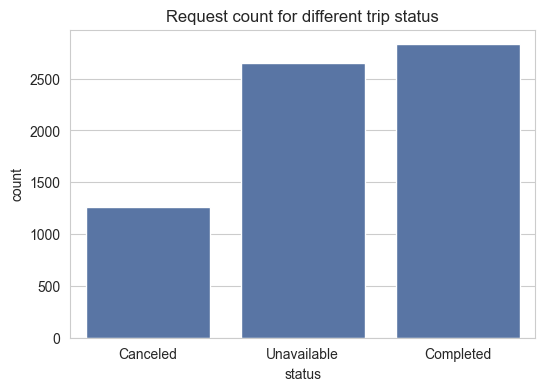

In [38]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="status")
plt.title("Request count for different trip status")
plt.show()

#### Feature Pickup Point

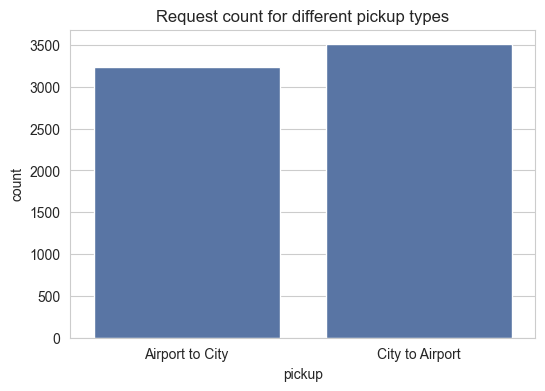

In [39]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="pickup")
plt.title("Request count for different pickup types")
plt.show()

### 5.2 Numerical Features

#### Feature Request Date

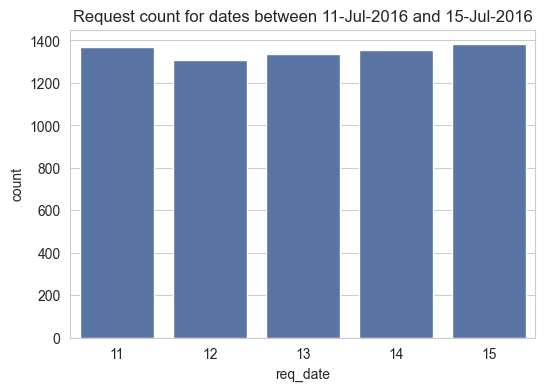

In [40]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="req_date")
plt.title("Request count for dates between 11-Jul-2016 and 15-Jul-2016")
plt.show()

#### Feature Request Weekday

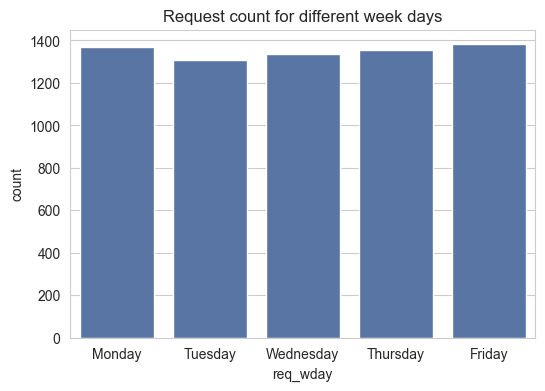

In [41]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="req_wday", order=weekdays)
plt.title("Request count for different week days")
plt.show()

#### Feature Request Hour

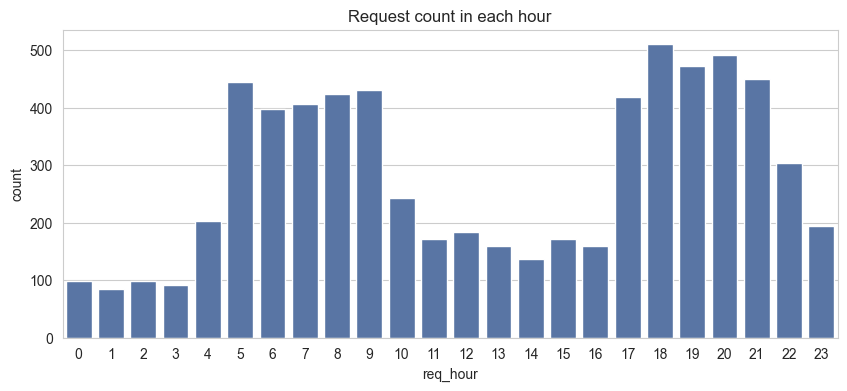

In [42]:
plt.figure(figsize=(10, 4))
sns.countplot(data=ub_df, x="req_hour")
plt.title("Request count in each hour")
plt.show()

#### Feature Drop Date

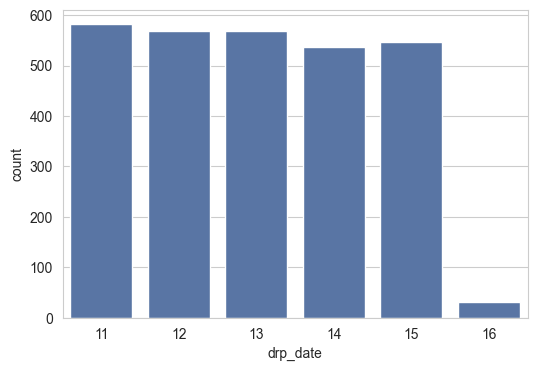

In [43]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="drp_date")
plt.show()

#### Feature Drop Weekday

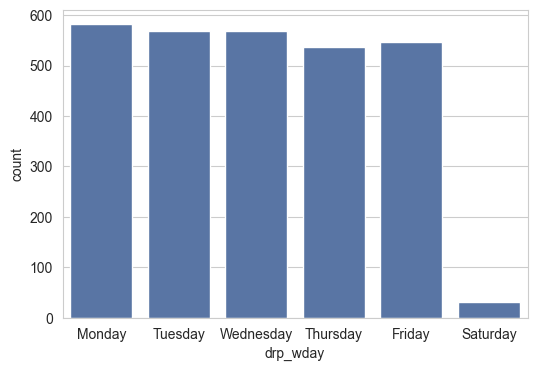

In [44]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="drp_wday")
plt.show()

#### Feature Drop Hour

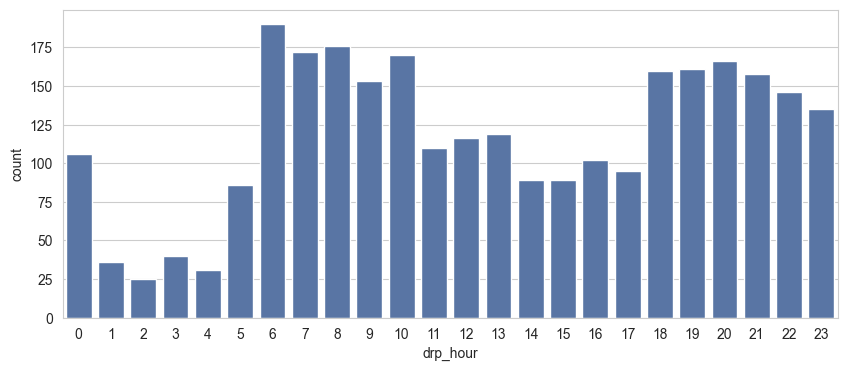

In [45]:
plt.figure(figsize=(10, 4))
sns.countplot(data=ub_df, x="drp_hour")
plt.show()

#### Feature Time Difference

In [46]:
ub_df["time_diff"].dt.total_seconds().describe().to_frame().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
time_diff,2831.00,3144.83,831.04,1247.00,2460.00,3125.00,3840.00,4980.00


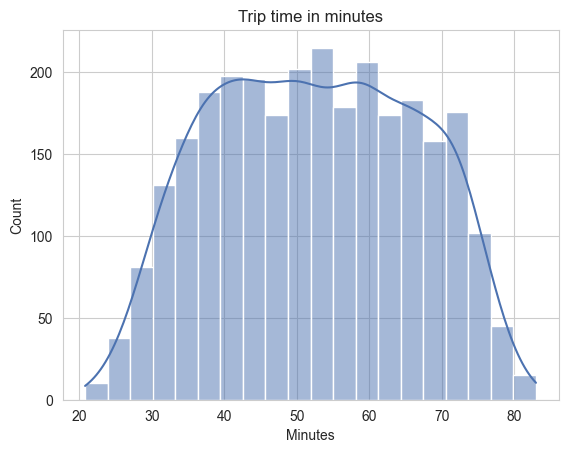

In [47]:
sns.histplot(x=ub_df["time_diff"].dt.total_seconds() / 60, kde=True)
plt.title("Trip time in minutes")
plt.xlabel("Minutes")
plt.show()

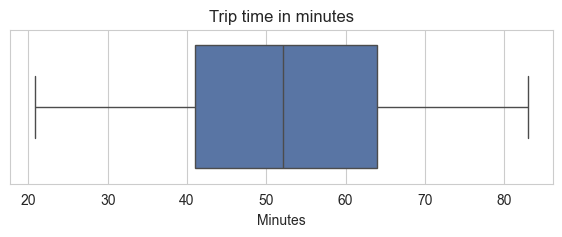

In [48]:
plt.figure(figsize=(7, 2))
sns.boxplot(x=ub_df["time_diff"].dt.total_seconds() / 60)
plt.title("Trip time in minutes")
plt.xlabel("Minutes")
plt.show()

#### Feature Daily Cancellation Rate

Frequency of booking requests getting canceled daily between 11th and 15th.

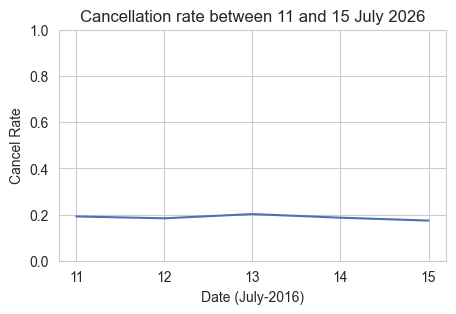

In [49]:
plt.figure(figsize=(5, 3))

sns.lineplot(data=dlm_df, x="req_date", y="cancel_rate")
plt.title("Cancellation rate between 11 and 15 July 2026")
plt.xlabel("Date (July-2016)")
plt.ylabel("Cancel Rate")
plt.xticks(range(11, 16))
plt.yticks(np.arange(0, 1.1, 0.2))

plt.show()

#### Feature Weekly Cancellation Rate

Days of week in which the cancellation rate is maximum.

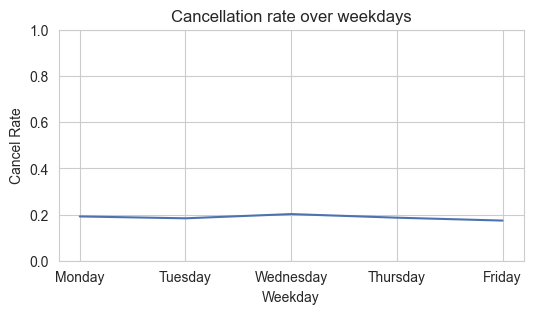

In [50]:
plt.figure(figsize=(6, 3))

sns.lineplot(data=wkm_df, x="req_wday", y="cancel_rate")
plt.title("Cancellation rate over weekdays")
plt.xlabel("Weekday")
plt.ylabel("Cancel Rate")
plt.yticks(np.arange(0, 1.1, 0.2))

plt.show()

#### Feature Hourly Demand-Supply-Gap

Time of day when the demand is highest and supply is low.

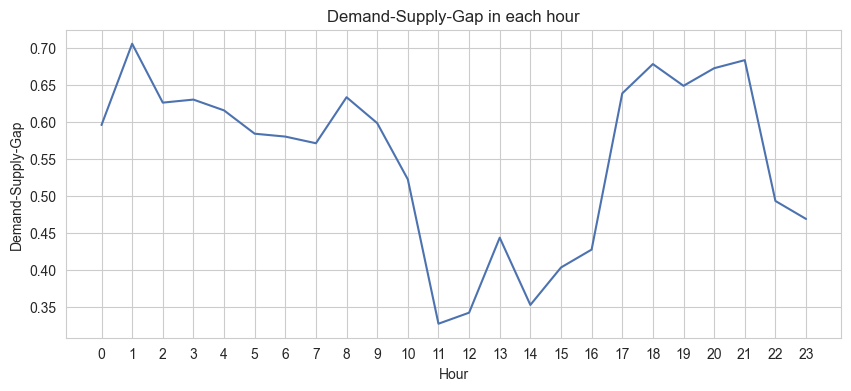

In [51]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=hrm_df, x="req_hour", y="ds_gap")
plt.title("Demand-Supply-Gap in each hour")
plt.xlabel("Hour")
plt.ylabel("Demand-Supply-Gap")
plt.xticks(range(0, 24))

plt.show()

##### Observations

1. Generally demand for cabs are high in two time ranges.
   - 12 AM to 10 AM
   - 05 PM to 10 PM
2. Demand is low between 11 AM and 4 PM.

#### Feature Hourly Cancellation Rate

Frequency of booking requests getting canceled every hour.

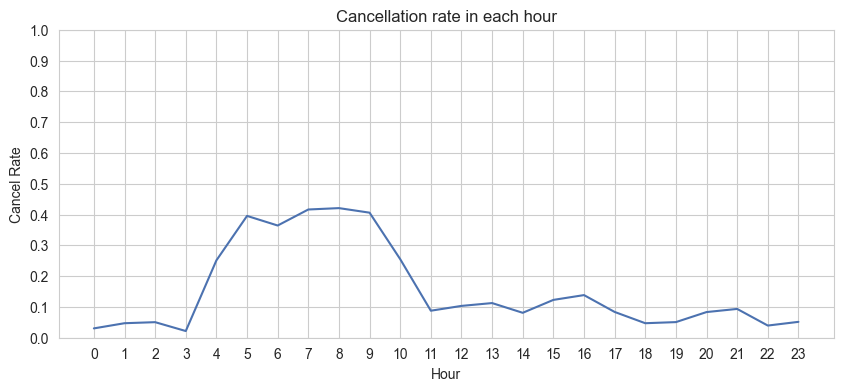

In [52]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=hrm_df, x="req_hour", y="cancel_rate")
plt.title("Cancellation rate in each hour")
plt.xlabel("Hour")
plt.ylabel("Cancel Rate")
plt.xticks(range(0, 24))
plt.yticks(np.arange(0, 1.1, 0.1))

plt.show()

##### Observations

1. Cancellation rate is high only between 4 AM and 10 AM in the morning.
2. Remaining hours have low cancellation rates.

#### Feature Hourly Availability Rate

Time of day when the cabs are available but demand is low.

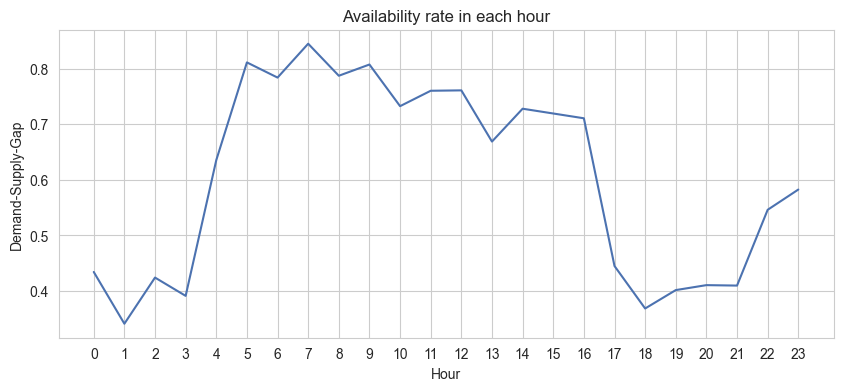

In [53]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=hrm_df, x="req_hour", y="avblty_rate")
plt.title("Availability rate in each hour")
plt.xlabel("Hour")
plt.ylabel("Demand-Supply-Gap")
plt.xticks(range(0, 24))

plt.show()

##### Observations

1. There is high availability of cabs between 4 AM and 4 PM.
2. Availability drops sharply post 5 PM in the evening and is low until 3 AM in the morning.

## 6 Bivariate Analysis

### 6.1 Categorical vs Categorical

#### Features `pickup` vs `status`

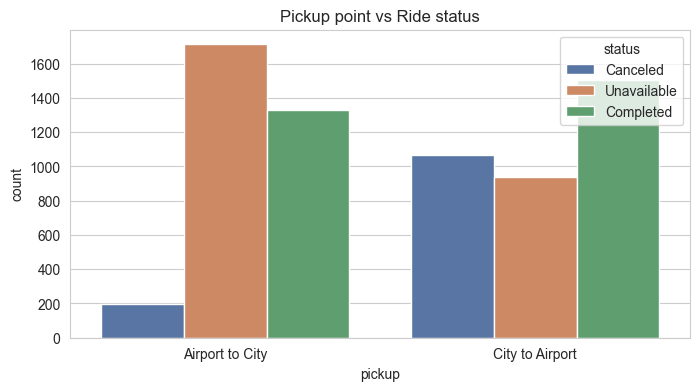

In [54]:
plt.figure(figsize=(8, 4))
sns.countplot(data=ub_df, x="pickup", hue="status")
plt.title("Pickup point vs Ride status")
plt.show()

### 6.2 Numerical vs Categorical

#### Features `req_date` vs `status`

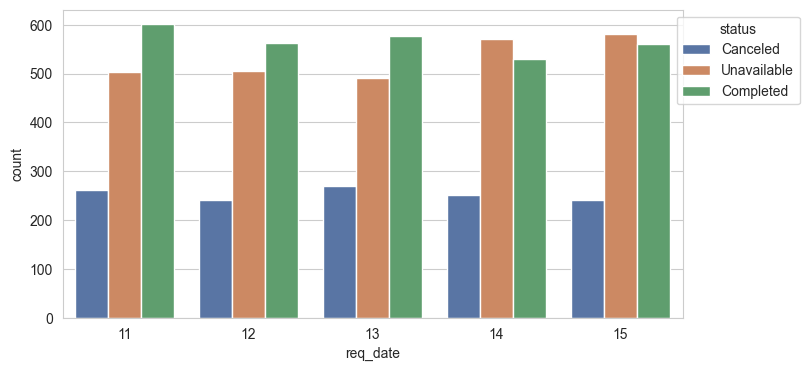

In [55]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=ub_df, x="req_date", hue="status")
ax.legend(title="status", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.show()

#### Features `req_date` vs `pickup`

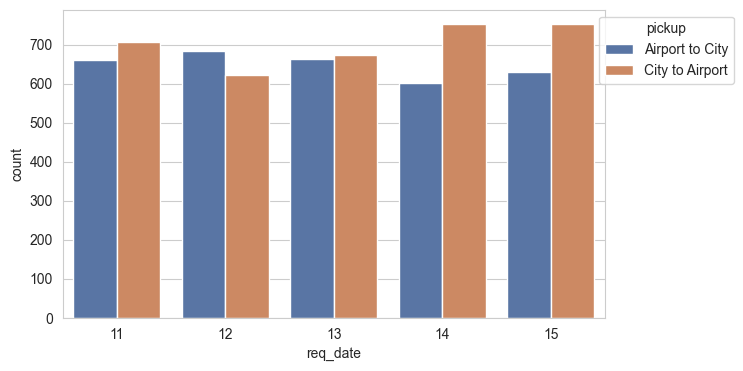

In [56]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=ub_df, x="req_date", hue="pickup")
ax.legend(title="pickup", loc="upper right", bbox_to_anchor=(1.25, 1))
plt.show()

#### Features `req_wday` vs `status`

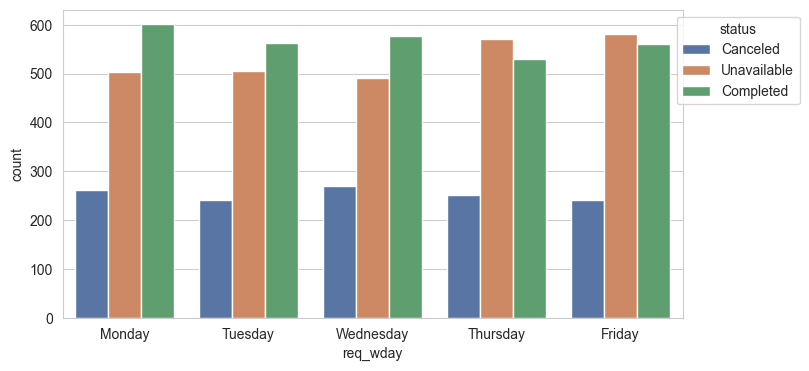

In [57]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=ub_df, x="req_wday", hue="status", order=weekdays)
ax.legend(title="status", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.show()

#### Features `req_wday` vs `pickup`

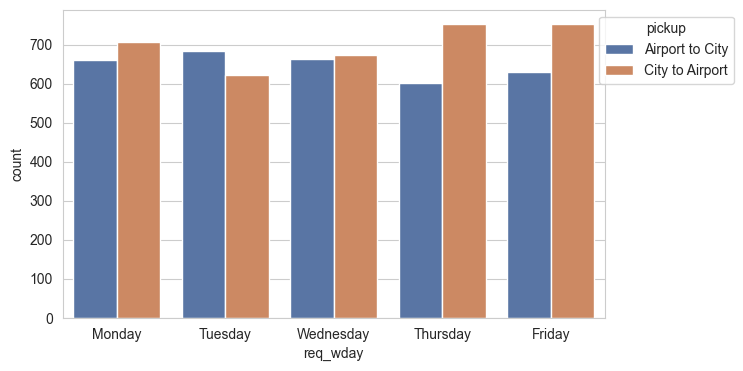

In [58]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=ub_df, x="req_wday", hue="pickup", order=weekdays)
ax.legend(title="pickup", loc="upper right", bbox_to_anchor=(1.25, 1))
plt.show()

#### Features `req_hour` vs `status`

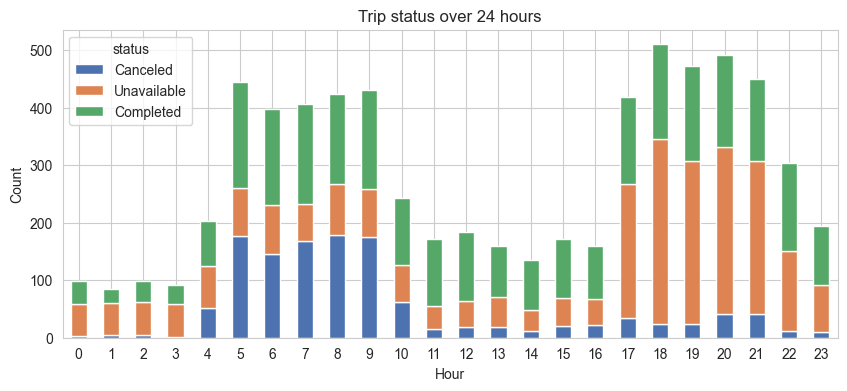

In [59]:
rs_ct = pd.crosstab(index=ub_df["req_hour"], columns=ub_df["status"])

ax = rs_ct.plot(kind="bar", stacked=True, figsize=(10, 4))
plt.title("Trip status over 24 hours")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

#### Features `req_hour` vs `pickup`

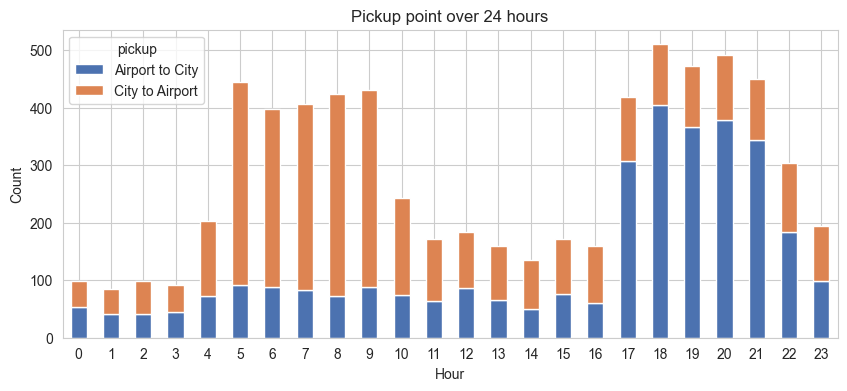

In [60]:
rp_ct = pd.crosstab(index=ub_df["req_hour"], columns=ub_df["pickup"])

ax = rp_ct.plot(kind="bar", stacked=True, figsize=(10, 4))
plt.title("Pickup point over 24 hours")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

#### Features `day_type` vs `status`

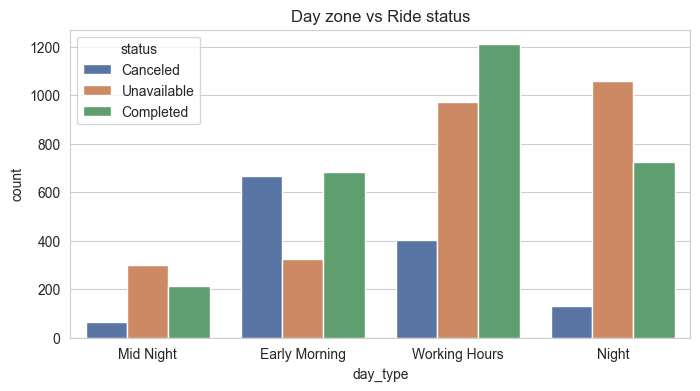

In [61]:
plt.figure(figsize=(8, 4))
sns.countplot(data=ub_df, x="day_type", hue="status")
plt.title("Day zone vs Ride status")
plt.show()

In [62]:
dtype_st_ct = pd.crosstab(index=ub_df["day_type"], columns=ub_df["status"])
dtype_st_ct

status,Canceled,Unavailable,Completed
day_type,,,
Mid Night,65,299,214
Early Morning,668,323,681
Working Hours,402,971,1210
Night,129,1057,726


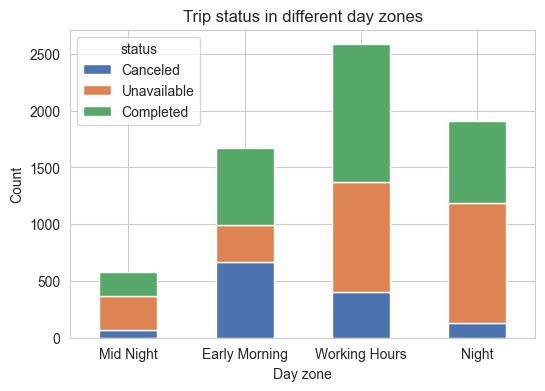

In [63]:
ax = dtype_st_ct.plot(kind="bar", stacked=True, figsize=(6, 4))
plt.title("Trip status in different day zones")
plt.xlabel("Day zone")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

#### Features `day_type` vs `pickup`

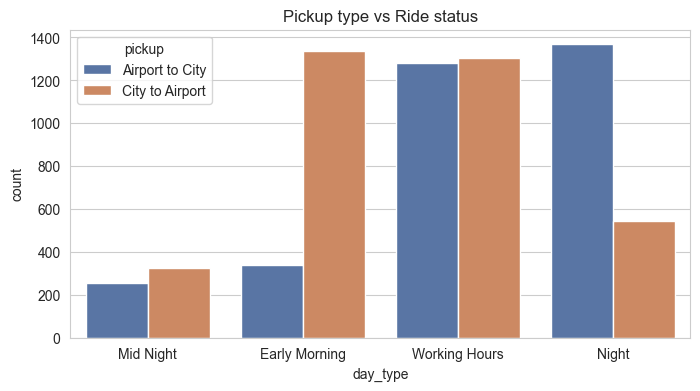

In [64]:
plt.figure(figsize=(8, 4))
sns.countplot(data=ub_df, x="day_type", hue="pickup")
plt.title("Pickup type vs Ride status")
plt.show()

#### Features `time_diff` vs `pickup`

In [65]:
ub_df["time_diff"].dt.total_seconds().describe().to_frame().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
time_diff,2831.00,3144.83,831.04,1247.00,2460.00,3125.00,3840.00,4980.00


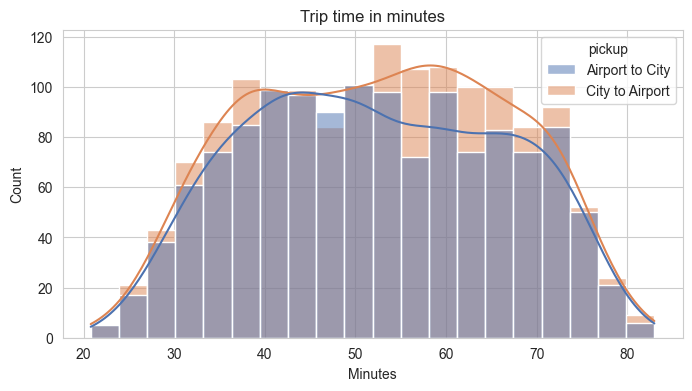

In [66]:
plt.figure(figsize=(8, 4))
sns.histplot(x=ub_df["time_diff"].dt.total_seconds() / 60, hue=ub_df["pickup"], kde=True)
plt.title("Trip time in minutes")
plt.xlabel("Minutes")
plt.show()

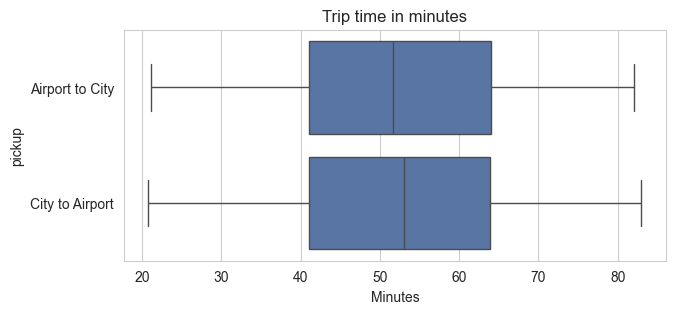

In [67]:
plt.figure(figsize=(7, 3))
sns.boxplot(x=ub_df["time_diff"].dt.total_seconds() / 60, y=ub_df["pickup"])
plt.title("Trip time in minutes")
plt.xlabel("Minutes")
plt.show()

### 6.3 Numerical vs Numerical

#### Features `avblty_rate` vs `cancel_rate`

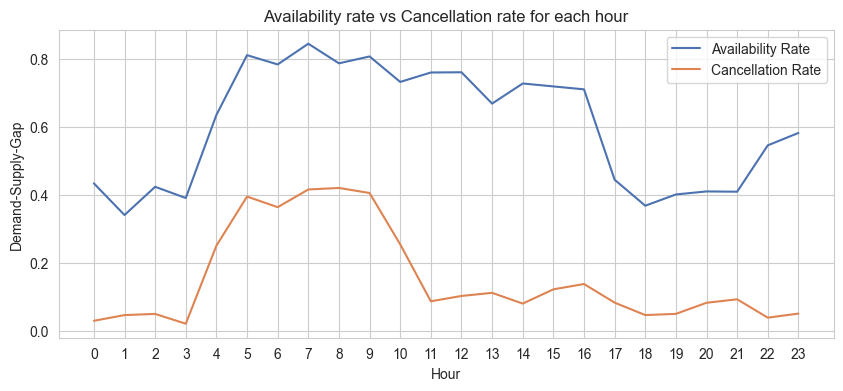

In [68]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=hrm_df, x="req_hour", y="avblty_rate", label="Availability Rate")
sns.lineplot(data=hrm_df, x="req_hour", y="cancel_rate", label="Cancellation Rate")
plt.title("Availability rate vs Cancellation rate for each hour")
plt.xlabel("Hour")
plt.ylabel("Demand-Supply-Gap")
plt.xticks(range(0, 24))

plt.show()

In [69]:
mask1 = ub_df["pickup"] == "Airport to City"
air_df = caculate_metrics(ub_df[mask1], "req_hour")

mask2 = ub_df["pickup"] == "City to Airport"
cty_df = caculate_metrics(ub_df[mask2], "req_hour")

##### Availability vs Cancellation (Airport-to-city route)

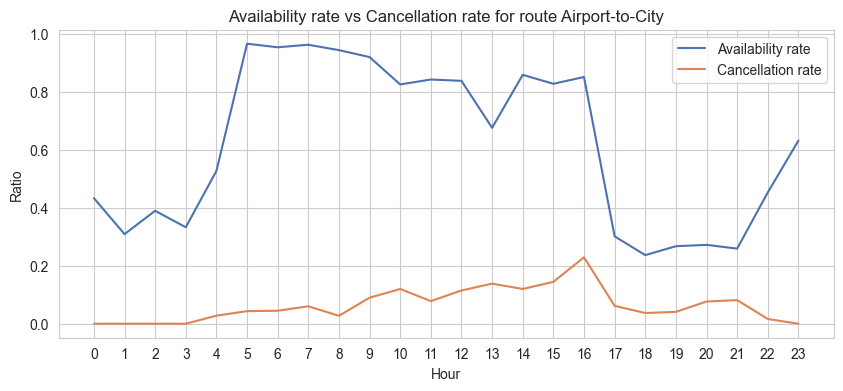

In [70]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=air_df, x="req_hour", y="avblty_rate", label="Availability rate")
sns.lineplot(data=air_df, x="req_hour", y="cancel_rate", label="Cancellation rate")
plt.title("Availability rate vs Cancellation rate for route Airport-to-City")
plt.xlabel("Hour")
plt.ylabel("Ratio")
plt.xticks(range(0, 24))

plt.show()

##### Availability vs Cancellation (City-to-Airport route)

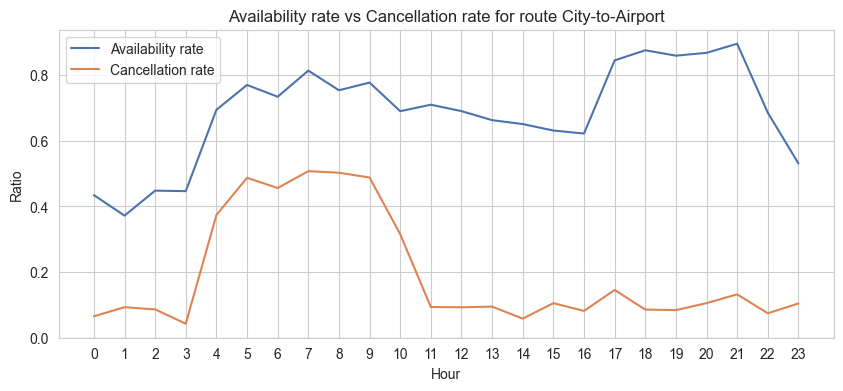

In [71]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=cty_df, x="req_hour", y="avblty_rate", label="Availability rate")
sns.lineplot(data=cty_df, x="req_hour", y="cancel_rate", label="Cancellation rate")
plt.title("Availability rate vs Cancellation rate for route City-to-Airport")
plt.xlabel("Hour")
plt.ylabel("Ratio")
plt.xticks(range(0, 24))

plt.show()

## 7 Multivariate Analysis

### 7.1 Numerical vs Categorical vs Categorical

#### Features `req_hour` vs `pickup` vs `status`

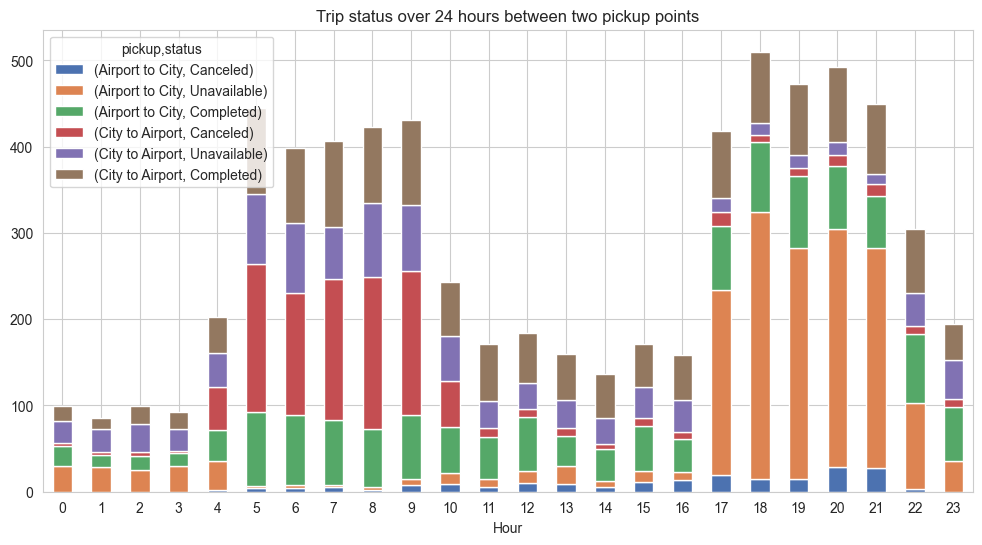

In [72]:
rhr_ps_ct = pd.crosstab(index=ub_df["req_hour"], columns=[ub_df["pickup"], ub_df["status"]])

ax = rhr_ps_ct.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Trip status over 24 hours between two pickup points")
plt.xlabel("Hour")
plt.xticks(rotation=0)

plt.show()

#### Features `day_type` vs `pickup` vs `status`

In [73]:
dtype_pk_st_ct = pd.crosstab(index=ub_df["day_type"], columns=[ub_df["pickup"], ub_df["status"]])
dtype_pk_st_ct

pickup        Airport to City                       City to Airport  \
status               Canceled Unavailable Completed        Canceled   
day_type                                                              
Mid Night                   2         148       103              63   
Early Morning              15          14       308             653   
Working Hours             106         618       556             296   
Night                      75         933       360              54   

pickup                               
status        Unavailable Completed  
day_type                             
Mid Night             151       111  
Early Morning         309       373  
Working Hours         353       654  
Night                 124       366

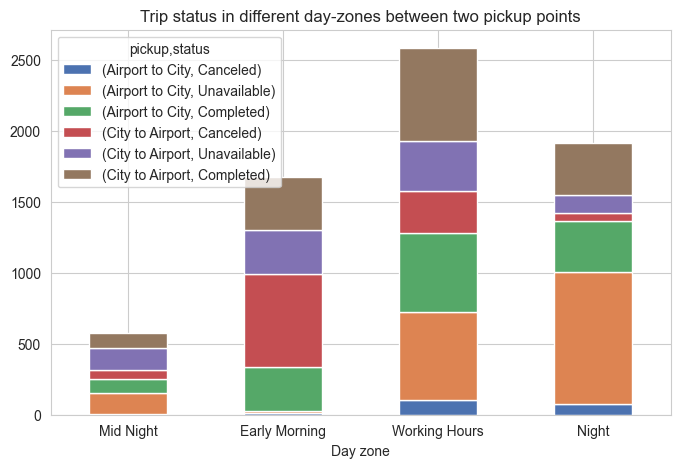

In [74]:
ax = dtype_pk_st_ct.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Trip status in different day-zones between two pickup points")
plt.xlabel("Day zone")
plt.xticks(rotation=0)

plt.show()

#### Features `req_wday` vs `pickup` vs `status`

In [75]:
rwd_ps_ct = pd.crosstab(
    index=ub_df["req_wday"],
    columns=[ub_df["pickup"], ub_df["status"]],
).reindex(weekdays)
rwd_ps_ct

pickup    Airport to City                       City to Airport              \
status           Canceled Unavailable Completed        Canceled Unavailable   
req_wday                                                                      
Monday                 42         338       281             220         166   
Tuesday                45         350       289             195         155   
Wednesday              48         317       298             222         173   
Thursday               32         378       191             220         193   
Friday                 31         330       268             209         250   

pickup               
status    Completed  
req_wday             
Monday          320  
Tuesday         273  
Wednesday       279  
Thursday        339  
Friday          293

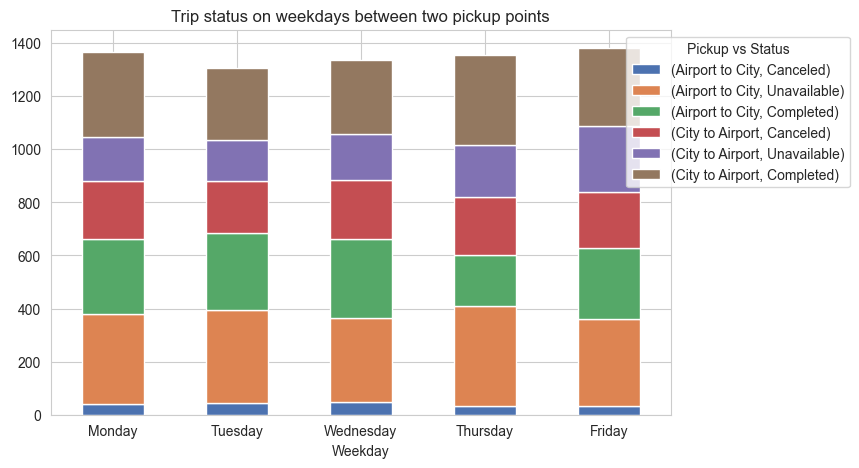

In [76]:
ax = rwd_ps_ct.plot(kind="bar", stacked=True, figsize=(8, 5))
ax.legend(title="Pickup vs Status", loc="upper right", bbox_to_anchor=(1.3, 1))

plt.title("Trip status on weekdays between two pickup points")
plt.xlabel("Weekday")
plt.xticks(rotation=0)

plt.show()

### 7.2 Numerical vs Numerical vs Categorical

#### Features Demand-Supply-Gap vs hours vs pickup

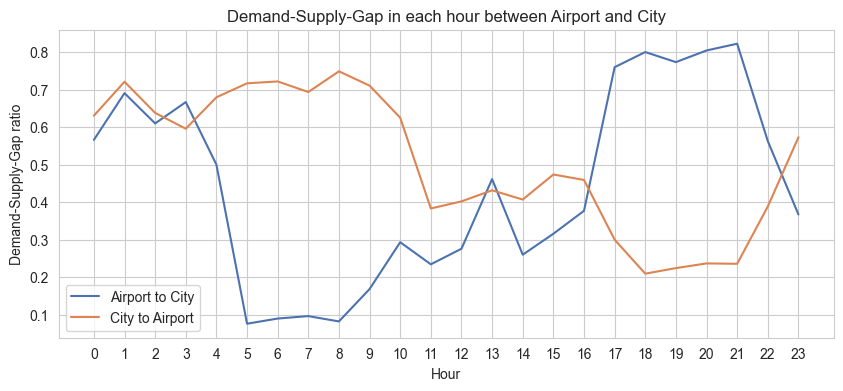

In [77]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=air_df, x="req_hour", y="ds_gap", label="Airport to City")
sns.lineplot(data=cty_df, x="req_hour", y="ds_gap", label="City to Airport")
plt.title("Demand-Supply-Gap in each hour between Airport and City")
plt.xlabel("Hour")
plt.ylabel("Demand-Supply-Gap ratio")
plt.xticks(range(0, 24))

plt.show()

#### Features Availability rate vs hours vs pickup

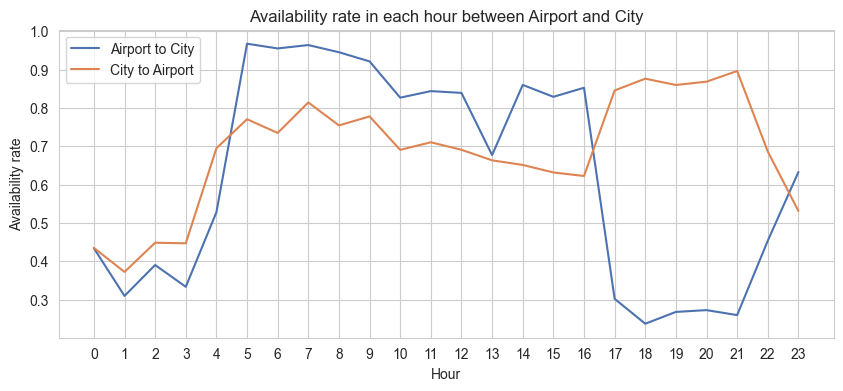

In [78]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=air_df, x="req_hour", y="avblty_rate", label="Airport to City")
sns.lineplot(data=cty_df, x="req_hour", y="avblty_rate", label="City to Airport")
plt.title("Availability rate in each hour between Airport and City")
plt.xlabel("Hour")
plt.ylabel("Availability rate")
plt.xticks(range(0, 24))

plt.show()

#### Features Cancellation rate vs hours vs pickup

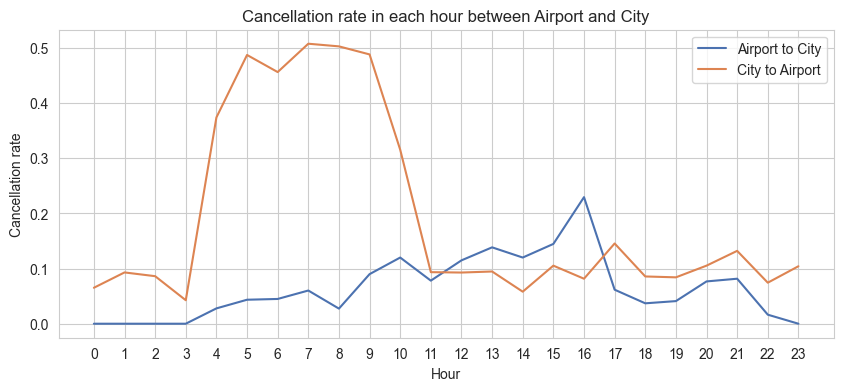

In [79]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=air_df, x="req_hour", y="cancel_rate", label="Airport to City")
sns.lineplot(data=cty_df, x="req_hour", y="cancel_rate", label="City to Airport")
plt.title("Cancellation rate in each hour between Airport and City")
plt.xlabel("Hour")
plt.ylabel("Cancellation rate")
plt.xticks(range(0, 24))

plt.show()

## 8 Root Cause Analysis